In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import statsmodels.api as sm
import statsmodels.tsa.api as tsa
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.forecasting.stl import STLForecast
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Part 1

Run both a non-robust and robust STL on the sunspots data from last homework using a period of m = 11.

In [3]:
# Load the sunspots data
sunspots = sm.datasets.sunspots.load_pandas().data

sunspots

,YEAR,SUNACTIVITY
0,1700.0,5.0
1,1701.0,11.0
2,1702.0,16.0
3,1703.0,23.0
4,1704.0,36.0
...,...,...
304,2004.0,40.4
305,2005.0,29.8
306,2006.0,15.2
307,2007.0,7.5


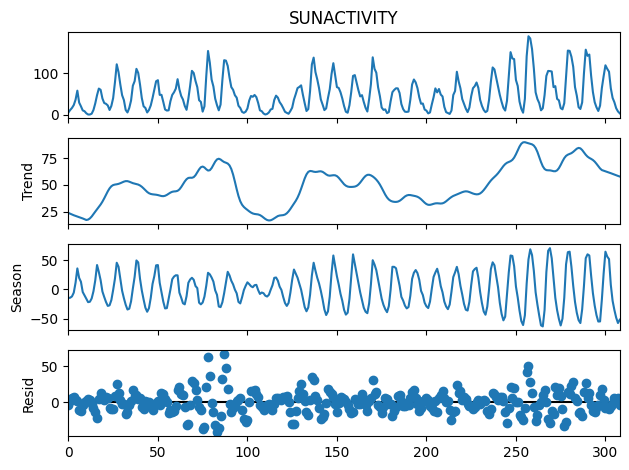

In [4]:
# Non-robust STL
stl_non_robust = tsa.STL(sunspots["SUNACTIVITY"], robust=False, period=11).fit()
plot = stl_non_robust.plot()
plot.show()

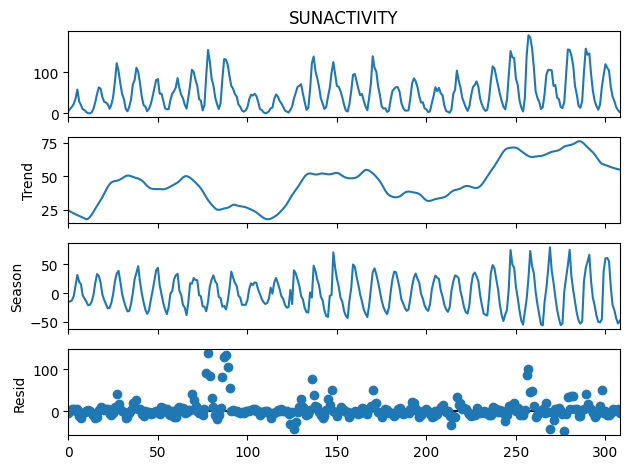

In [5]:
# Robust STL
stl_robust = tsa.STL(sunspots["SUNACTIVITY"], robust=True, period=11).fit()
plot = stl_robust.plot()
plot.show()

# Part 2

Comment on the differences, is either method clearly superior?

Let's compare the graphs.

First, looking at the Trend graph, we can see that the non-robust STL decomposition has more of a shaky trend compared to the robust STL decomposition. I believe the robust STL decomposition has tuned out the oscillations better and gives us a clearer view of the rise in activity between 25-75, 125-175, and 225-375. We can also see the robust STL decomposition not crater like the non-robust decomposition around the 110 year mark (likely due to being more resistant to outliers).

Next, looking at the Season graph, the robust STL decomposition may look a little better than the non-robust STL decomposition. We're looking for a more consistent regular pattern trying to capture the oscillations of the time series data. Once again, we see the signal for the oscillations die out around 100-110 for the non-robust STL decomposition whereas the robust STL decomposition is more resistant to this lower outlier.

Finally, looking at the Resid graph, we can once again see that the robust STL decomposition is superior. The ideal situation is that most of the data is centered around 0 with a variance of 1 as white noise so we can pick out the outliers. With the non-robust STL decomposition, we can see that all of the residuals are too spread out making outliers hard to pick out. On the other hand, with the robust STL decomposition, we can see the points tightly clustered around 0 giving us clear indicators or outliers at 25, 75, 140, 170, and 260.

All in all, it looks like robust STL decomposition is clearly superior.

# Part 3

Use the ACF and PACF of the robust STL trend to determine p and q orders for ARMA, and use STLForecast with your chosen ARMA model to predict sunspot activity through 2050. Plot your results and comment on whether they seem reasonable.

In [6]:
# Make sure series is stationary before finding ACF and PACF for p and q
# Looked online to see how I could verify correct differencing, found Augmented Dickey-Fuller test
trend = stl_robust.trend
print(f"No difference, p-value: {adfuller(trend)[1]}")
trend_diff1 = trend.diff().dropna()
print(f"First Order Difference, p-value: {adfuller(trend_diff1)[1]}")

No difference, p-value: 0.2746131971122491
First Order Difference, p-value: 3.126845559533079e-07


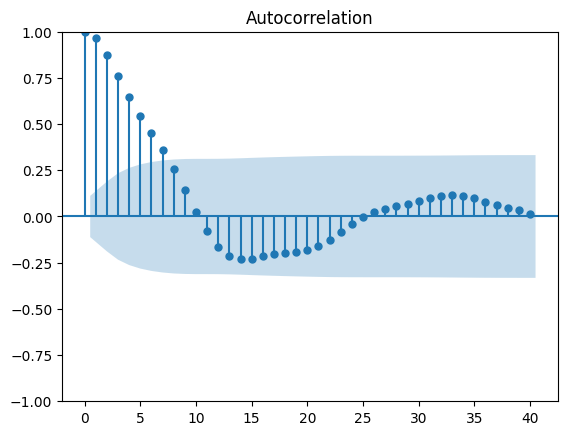

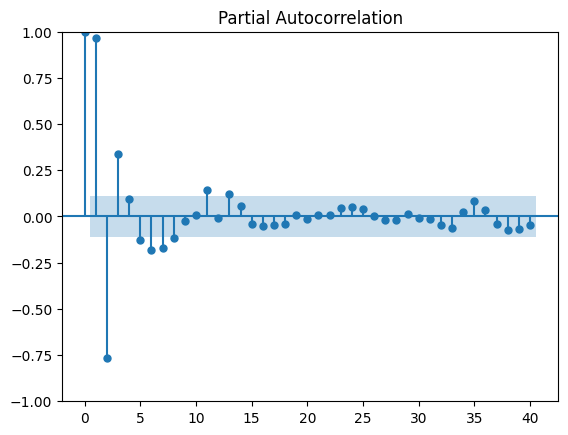

In [7]:
# Plot ACF and PACF of differenced trend
plot_acf(trend_diff1, lags=40)
plot_pacf(trend_diff1, lags=40)
plt.show()

In [8]:
# Chosen ARMA model
stl_forecast = STLForecast(sunspots['SUNACTIVITY'],
                           model=ARIMA,
                           model_kwargs={"order":(4, 1, 0)},
                           period=11,
                           robust=True,
                           ).fit()

stl_forecast.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                    STL Decomposition and SARIMAX Results                     
==============================================================================
Dep. Variable:                      y   No. Observations:                  309
Model:                 ARIMA(4, 1, 0)   Log Likelihood               -1315.755
Date:                Thu, 30 Oct 2025   AIC                           2641.510
Time:                        06:44:15   BIC                           2660.160
Sample:                             0   HQIC                          2648.967
                                - 309                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0249      0.034     -0.724      0.469      -0.092       0.043
ar.L2         -0.0550      0.040     -1.365      0.172      -0.134       0.024
ar.L3         -0.1528      0.051     -2.995      0.003      -0.253      -0.053
ar.L4         -0.2663      0.058     -4.598      0.000      -0.380      -0.153
sigma2       300.2968     14.630     20.526      0.000     271.622     328.972
===================================================================================
Ljung-Box (L1) (Q):                   1.17   Jarque-Bera (JB):               268.63
Prob(Q):                              0.28   Prob(JB):                         0.00
Heteroskedasticity (H):               1.11   Skew:                             0.86
Prob(H) (two-sided):                  0.61   Kurtosis:                         7.24
                                STL Configuration                                
=================================================================================
Period:                            11       Trend Length:                      21
Seasonal:                           7       Trend deg:                          1
Seasonal deg:                       1       Trend jump:                         1
Seasonal jump:                      1       Low pass:                          13
Robust:                          True       Low pass deg:                       1
---------------------------------------------------------------------------------

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [9]:
# Data ends at 2008
# 2050 - 2008 = 42 timesteps
forecast = stl_forecast.forecast(42)

# Plot forecasted results appended to data
forecast_df = pd.DataFrame(forecast, columns=["Forecasted Sunactivity"])

fig = px.line(data_frame=sunspots,
              x=sunspots.index,
              y="SUNACTIVITY",
              title="Sunactivity with Forecast",
              labels={"x": "Date", "SUNACTIVITY": "Sunactivity"},
              template="seaborn",
              )
fig.add_trace(px.line(data_frame=forecast_df,
              x=forecast_df.index,
              y="Forecasted Sunactivity",
              title="Sunactivity",
              labels={"x": "Date", "SUNACTIVITY": "Sunactivity"},
              template="seaborn",
              color_discrete_sequence=["red"],
              ).data[0])
fig.update_layout(title_font_size=30,
                xaxis_tickfont_size=18,
                yaxis_tickfont_size=18,
                xaxis_title_font_size=25,
                yaxis_title_font_size=25,
                plot_bgcolor='rgba(0,0,0,0)'
                )
fig.show()

Are the results in red reasonable?

I believe so. While there is a caveat of the forecast all looking uniform in their oscillations, the shape and magnitude of the seasons/trend look incredibly representative of the average time series data before it.

# Part 4

Use Holt-Winters' method (with a seasonal period of 11 and additive trend and seasonal components) to predict sunspot activity through 2050. Plot the results and comment on whether they seem reasonable, and if they are better or worse than the results obtained part 3.

In [11]:
# We want to use Triple Exponential Smoothing (Same as Holt-Winters Method)
# Citation: This following is taken from exponential_smoothing_demo.ipynb provided in class and modified

holt_winters_model = tsa.ExponentialSmoothing(endog=sunspots["SUNACTIVITY"],
                                               trend="add",
                                               seasonal="add",
                                               seasonal_periods=11,
                                              ).fit()

# Forecast up to 2050
holt_winters_forecast = holt_winters_model.forecast(42)

# Plot forecasted results (Appended to end of real results)
forecast_df = pd.DataFrame(holt_winters_forecast, columns=["Forecasted Sunactivity"])

fig = px.line(data_frame=sunspots,
              x=sunspots.index,
              y="SUNACTIVITY",
              title="Sunactivity with Forecast",
              labels={"x": "Date", "SUNACTIVITY": "Sunactivity"},
              template="seaborn",
              )
fig.add_trace(px.line(data_frame=forecast_df,
              x=forecast_df.index,
              y="Forecasted Sunactivity",
              title="Sunactivity",
              labels={"x": "Date", "SUNACTIVITY": "Sunactivity"},
              template="seaborn",
              color_discrete_sequence=["red"],
              ).data[0])
fig.update_layout(title_font_size=30,
                xaxis_tickfont_size=18,
                yaxis_tickfont_size=18,
                xaxis_title_font_size=25,
                yaxis_title_font_size=25,
                plot_bgcolor='rgba(0,0,0,0)'
                )
fig.show()

Are the results reasonable and are they better or worse than the results in Part 3?

I thing the results are reasonable (plausible?) but slightly worse than the results in Part 3. The seasonal cycles are correct, but the magnitude seems too small.

The reason for this is because while the results in Part 4 using the Holt-Winters Method shows plausible results with the seasonal oscillations, it fails to capture the slight upward trend that is present.

When looking at the trend graph for Robust STL decomposition in Part 1, we can see that while there are longer 100 year cycles the line is slowly going up. Taking that into account, I would expect the predictions to reflect that trend and maybe place more weight on newer data points.